In [5]:
import sys
sys.path.insert(0, "/srv/user/azhar.akhmetova/corrViT/analysis/src")
import os
import pickle
import matplotlib
import numpy as np
import torch
from tqdm import tqdm
import typing as t
import argparse
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.ndimage import center_of_mass

from v1t.utils import utils, tensorboard
from v1t import losses, data
from v1t.models.model import Model
from v1t.utils.scheduler import Scheduler

from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

utils.set_random_seed(1234)

tensorboard.set_font()

In [6]:
out_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_0_2dpe_bef_core"

In [52]:
parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="/user/azhar.akhmetova/corrViT/refactor/data/sensorium")
parser.add_argument("--output_dir", type=str, required=True)
parser.add_argument("--batch_size", type=int, default=10)
parser.add_argument("--device", type=str, default="cuda:3")

args = parser.parse_args([
    "--output_dir", f"{out_dir}",
])

In [53]:
if not os.path.isdir(args.output_dir):
    raise FileNotFoundError(f"Cannot find {args.output_dir}.")

utils.get_device(args)
utils.set_random_seed(1234)

utils.load_args(args)

train_ds, val_ds, test_ds = data.get_training_ds(
    args,
    data_dir=args.dataset,
    mouse_ids=args.mouse_ids,
    batch_size=args.batch_size,
    device=args.device,
)

model = Model(args, ds=val_ds)
model.eval()

scheduler = Scheduler(args, model=model, save_optimizer=False)
scheduler.restore(force=True)

scaler = GradScaler(enabled=args.amp)

image shape (1, 144, 256)
num_output_neurons {'k_4_a_03_xyz_b1e7_poisson': (7334,)}
Enable gradient checkpointing in ViT
Missing: []
Unexpected: ['neuron_coord_pe.weight', 'neuron_coord_pe.bias']

Loaded checkpoint from epoch 126 (correlation: 0.2564).



In [36]:
@torch.no_grad()
def compute_metrics(y_true: torch.Tensor, y_pred: torch.Tensor):
    """Metrics to compute as part of training and validation step"""
    msse = losses.msse(y_true=y_true, y_pred=y_pred)
    poisson_loss = losses.poisson_loss(y_true=y_true, y_pred=y_pred)
    correlation = losses.correlation(y1=y_pred, y2=y_true, dim=0)
    correlation = torch.mean(correlation)
    bits_per_spike = losses.bits_per_spike(y_true=y_true, y_pred=y_pred)
    return {
        "metrics/msse": msse,
        "metrics/poisson_loss": poisson_loss,
        "metrics/single_trial_correlation": correlation,
        "metrics/bits_per_spike": bits_per_spike,
    }

def evaluate_model(
    ds: t.Dict,
    model: Model,
    device: torch.device,
    verbose: bool = True,
):
    model.to(device).eval()
    results = {}
    for mouse_id, ds in ds.items():
        frac_input_neurons = getattr(model, "frac_input_neurons", 0.0)
        print(f"Fraction of input neurons: {frac_input_neurons}")
        N = ds.dataset.num_neurons
        print(f"N neurons: {N}")
        
        all_results = []  # Store results from each iteration

        if frac_input_neurons == 0.:
            targets, predictions = [], [] 
            for batch in tqdm(ds, desc=f"Mouse {mouse_id}", disable=not verbose):
                with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                    y_true = batch["response"].to(device)
                    y_pred, _, _ = model(
                            images=batch["image"].to(device),
                            responses=batch["response"].to(device),
                            neuron_coords=batch["neuron_coordinates"].to(device),
                            input_neuron_ids=None,
                            query_neuron_ids=torch.arange(N).to(device),
                            mouse_id=mouse_id,
                            behaviors=batch["behavior"].to(device),
                            pupil_centers=batch["pupil_center"].to(device),
                        )
                    targets.append(y_true)
                    predictions.append(y_pred)
                        
            targets = torch.vstack(targets).cpu()
            predictions = torch.vstack(predictions).cpu()
            
            # Compute metrics for this iteration
            results[mouse_id] = compute_metrics(y_true=targets, y_pred=predictions)
            
            del targets, predictions
            torch.cuda.empty_cache()

        else:
            for i in range(25):  # repeat evaluation n times with different input/query split
                perm = torch.randperm(N, device=device)
                K = int(frac_input_neurons * N)
                input_neuron_ids = perm[:K].to(device)
                print(f"Iteration {i+1}: Using {len(input_neuron_ids)} input neurons.")
                query_neuron_ids = perm[K:].to(device)
                targets, predictions = [], [] 
                
                for batch in tqdm(ds, desc=f"Mouse {mouse_id} - Iter {i+1}/25", disable=not verbose):
                    with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                        y_true = batch["response"].to(device)[:, query_neuron_ids]
                        y_pred, _, _ = model(
                                images=batch["image"].to(device),
                                responses=batch["response"].to(device),
                                neuron_coords=batch["neuron_coordinates"].to(device),
                                input_neuron_ids=input_neuron_ids,
                                query_neuron_ids=query_neuron_ids,
                                mouse_id=mouse_id,
                                behaviors=batch["behavior"].to(device),
                                pupil_centers=batch["pupil_center"].to(device),
                            )
                        targets.append(y_true)
                        predictions.append(y_pred)
                        
                targets = torch.vstack(targets).cpu()
                predictions = torch.vstack(predictions).cpu()
                
                # Compute metrics for this iteration
                iteration_results = compute_metrics(y_true=targets, y_pred=predictions)
                all_results.append(iteration_results)
                
                del targets, predictions

            # Aggregate results across all iterations
            mouse_results = {}
            for key in all_results[0].keys():
                values = [result[key].item() if hasattr(result[key], 'item') else result[key] 
                        for result in all_results]
                mouse_results[f"{key}_mean"] = np.mean(values)
                mouse_results[f"{key}_std"] = np.std(values)
                mouse_results[f"{key}_all"] = values
        
            results[mouse_id] = mouse_results

        torch.cuda.empty_cache()

    return results

In [54]:
mouse_results_0 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

Fraction of input neurons: 0.0
N neurons: 7334


Mouse k_4_a_03_xyz_b1e7_poisson: 100%|██████████| 252/252 [00:03<00:00, 65.85it/s]


In [ ]:
mouse_results_001 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_005 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_01 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_02 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_03 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_04 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_05 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_10 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_20 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [ ]:
mouse_results_25 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

In [18]:
mouse_results_50 = evaluate_model(
    ds=val_ds,
    model=model,
    device=args.device,
    verbose=True,
)

Fraction of input neurons: 0.5
N neurons: 7334
Iteration 1: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 1/25:   0%|          | 0/503 [00:00<?, ?it/s]

Mouse k_4_a_03_xyz_b1e7_poisson - Iter 1/25: 100%|██████████| 503/503 [00:10<00:00, 48.99it/s]


Iteration 2: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 2/25: 100%|██████████| 503/503 [00:10<00:00, 49.98it/s]


...

Mouse k_4_a_03_xyz_b1e7_poisson - Iter 23/25: 100%|██████████| 503/503 [00:11<00:00, 42.24it/s]


Iteration 24: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 24/25: 100%|██████████| 503/503 [00:09<00:00, 50.93it/s]


Iteration 25: Using 3667 input neurons.


Mouse k_4_a_03_xyz_b1e7_poisson - Iter 25/25: 100%|██████████| 503/503 [00:11<00:00, 43.81it/s]


In [55]:
mouse_results_0

{'k_4_a_03_xyz_b1e7_poisson': {'metrics/msse': tensor(17476054.),
  'metrics/poisson_loss': tensor(nan),
  'metrics/single_trial_correlation': tensor(0.2564),
  'metrics/bits_per_spike': tensor(nan)}}

In [98]:
mouse_results_001['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.258051335811615,
 0.25801998376846313,
 0.2579527199268341,
 0.25796568393707275,
 0.2580922544002533,
 0.2580069899559021,
 0.258113294839859,
 0.2580700218677521,
 0.2580031752586365,
 0.25801804661750793,
 0.2579568326473236,
 0.2580304741859436,
 0.2580198347568512,
 0.25797343254089355,
 0.2580455541610718,
 0.2580353915691376,
 0.2580430209636688,
 0.2579975426197052,
 0.2580791115760803,
 0.25809961557388306,
 0.25807181000709534,
 0.25800853967666626,
 0.258048415184021,
 0.2579880654811859,
 0.25800296664237976]

In [116]:
mouse_results_005['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3568817675113678,
 0.3548751473426819,
 0.35691165924072266,
 0.35603001713752747,
 0.3577277660369873,
 0.3544096350669861,
 0.3514642119407654,
 0.3521657884120941,
 0.3615914583206177,
 0.35479483008384705,
 0.3585887849330902,
 0.35818079113960266,
 0.35257571935653687,
 0.35778579115867615,
 0.36230936646461487,
 0.3528114855289459,
 0.3585079312324524,
 0.3586668074131012,
 0.3580417037010193,
 0.35591909289360046,
 0.36109527945518494,
 0.3476230502128601,
 0.35850149393081665,
 0.36029213666915894,
 0.3536182940006256]

In [74]:
mouse_results_01['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.25923797488212585,
 0.25917503237724304,
 0.2593182623386383,
 0.2592555284500122,
 0.2591196298599243,
 0.2593919336795807,
 0.25933587551116943,
 0.25937598943710327,
 0.259007066488266,
 0.2591848373413086,
 0.2591002583503723,
 0.25936928391456604,
 0.25910475850105286,
 0.25917550921440125,
 0.2594023644924164,
 0.2590111494064331,
 0.2596144676208496,
 0.2591942548751831,
 0.25925663113594055,
 0.2593444585800171,
 0.25951141119003296,
 0.25918048620224,
 0.2593400478363037,
 0.2595295011997223,
 0.2592930495738983]

In [106]:
mouse_results_02['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.24138952791690826,
 0.24248968064785004,
 0.24188759922981262,
 0.2432107925415039,
 0.24146805703639984,
 0.24345450103282928,
 0.2398439347743988,
 0.24213562905788422,
 0.2428814321756363,
 0.23824428021907806,
 0.24079261720180511,
 0.23930811882019043,
 0.23802606761455536,
 0.24180838465690613,
 0.24098941683769226,
 0.24210397899150848,
 0.24370989203453064,
 0.24022187292575836,
 0.24355703592300415,
 0.24090401828289032,
 0.24184119701385498,
 0.2397439330816269,
 0.24115608632564545,
 0.2432534098625183,
 0.24316036701202393]

In [111]:
mouse_results_03['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3904918134212494,
 0.39082109928131104,
 0.3916454613208771,
 0.39071500301361084,
 0.3909330368041992,
 0.3904931843280792,
 0.3909105658531189,
 0.3908270001411438,
 0.3917263448238373,
 0.3910253345966339,
 0.39054563641548157,
 0.3908163905143738,
 0.39036107063293457,
 0.3904869258403778,
 0.3907501995563507,
 0.390420526266098,
 0.39133840799331665,
 0.39084392786026,
 0.3908572793006897,
 0.3909772038459778,
 0.3909936249256134,
 0.39064881205558777,
 0.3913569450378418,
 0.39128202199935913,
 0.39080896973609924]

In [126]:
mouse_results_04['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.2584635019302368,
 0.25796079635620117,
 0.2583557069301605,
 0.2581055462360382,
 0.2581554055213928,
 0.2584272623062134,
 0.2584546208381653,
 0.25843921303749084,
 0.25796788930892944,
 0.2580074965953827,
 0.2582769989967346,
 0.2583388388156891,
 0.25819697976112366,
 0.25838175415992737,
 0.25833389163017273,
 0.25793543457984924,
 0.25923848152160645,
 0.25832563638687134,
 0.2580029368400574,
 0.2588540315628052,
 0.25861626863479614,
 0.258124977350235,
 0.25892505049705505,
 0.25862932205200195,
 0.25812196731567383]

In [121]:
mouse_results_05['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3984614908695221,
 0.3980090022087097,
 0.3987235724925995,
 0.3982028067111969,
 0.3982856869697571,
 0.3980829417705536,
 0.39849159121513367,
 0.3983011245727539,
 0.39836055040359497,
 0.39815109968185425,
 0.3981981575489044,
 0.3979378640651703,
 0.39798665046691895,
 0.3980126976966858,
 0.3978317379951477,
 0.39791351556777954,
 0.3987949788570404,
 0.3983127772808075,
 0.3982385993003845,
 0.3989439308643341,
 0.3986104428768158,
 0.398027241230011,
 0.39896872639656067,
 0.39854663610458374,
 0.3978584110736847]

In [44]:
mouse_results_10['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.4007522165775299,
 0.4006712734699249,
 0.4007580876350403,
 0.4009142220020294,
 0.40085676312446594,
 0.40037667751312256,
 0.40087011456489563,
 0.40092459321022034,
 0.40066275000572205,
 0.4002196788787842,
 0.4006541967391968,
 0.39972537755966187,
 0.40120387077331543,
 0.4001415967941284,
 0.40055209398269653,
 0.40132850408554077,
 0.40114033222198486,
 0.40071505308151245,
 0.4002808630466461,
 0.4008259177207947,
 0.4010394513607025,
 0.40082430839538574,
 0.4012332856655121,
 0.401387482881546,
 0.4008913040161133]

In [131]:
mouse_results_20['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.40282902121543884,
 0.40260079503059387,
 0.4012669622898102,
 0.4026203155517578,
 0.40229424834251404,
 0.40232202410697937,
 0.4029025435447693,
 0.40110212564468384,
 0.40163570642471313,
 0.4024966359138489,
 0.4022078812122345,
 0.40172407031059265,
 0.4035228490829468,
 0.40157121419906616,
 0.40261971950531006,
 0.4031052887439728,
 0.40225064754486084,
 0.4030740559101105,
 0.4024447202682495,
 0.4026373326778412,
 0.4023851156234741,
 0.40347516536712646,
 0.4029737710952759,
 0.40260860323905945,
 0.40228304266929626]

In [136]:
mouse_results_25['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.3981967270374298,
 0.39741265773773193,
 0.39710623025894165,
 0.39774906635284424,
 0.39802736043930054,
 0.39750465750694275,
 0.3986388146877289,
 0.39729562401771545,
 0.3969642221927643,
 0.397491991519928,
 0.39774417877197266,
 0.3970372676849365,
 0.39958861470222473,
 0.3973930776119232,
 0.398682564496994,
 0.39888298511505127,
 0.3976772427558899,
 0.39799949526786804,
 0.3980712592601776,
 0.3984406888484955,
 0.39764559268951416,
 0.399168998003006,
 0.3984704315662384,
 0.3977201282978058,
 0.39759886264801025]

In [19]:
mouse_results_50['k_4_a_03_xyz_b1e7_poisson']['metrics/single_trial_correlation_all']

[0.4005199074745178,
 0.4003540873527527,
 0.40023893117904663,
 0.4025235176086426,
 0.4000215232372284,
 0.3995729088783264,
 0.4007822871208191,
 0.4004792273044586,
 0.402827650308609,
 0.40083613991737366,
 0.39963892102241516,
 0.3994837701320648,
 0.40444567799568176,
 0.39705049991607666,
 0.40099814534187317,
 0.4016836881637573,
 0.4008188545703888,
 0.39949366450309753,
 0.4026883542537689,
 0.40399491786956787,
 0.40088626742362976,
 0.40213775634765625,
 0.4005368649959564,
 0.4004305601119995,
 0.4013611972332001]

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Data extracted from outputs
fractions = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 10, 20, 25, 50]

# Correlation values for each fraction
correlations_data = {
    0: [0.2564], 
    0.01: [0.258051335811615, 0.25801998376846313, 0.2579527199268341, 0.25796568393707275, 0.2580922544002533, 0.2580069899559021, 0.258113294839859, 0.2580700218677521, 0.2580031752586365, 0.25801804661750793, 0.2579568326473236, 0.2580304741859436, 0.2580198347568512, 0.25797343254089355, 0.2580455541610718, 0.2580353915691376, 0.2580430209636688, 0.2579975426197052, 0.2580791115760803, 0.25809961557388306, 0.25807181000709534, 0.25800853967666626, 0.258048415184021, 0.2579880654811859, 0.25800296664237976],
    
    0.05: [0.3568817675113678, 0.3548751473426819, 0.35691165924072266, 0.35603001713752747, 0.3577277660369873, 0.3544096350669861, 0.3514642119407654, 0.3521657884120941, 0.3615914583206177, 0.35479483008384705, 0.3585887849330902, 0.35818079113960266, 0.35257571935653687, 0.35778579115867615, 0.36230936646461487, 0.3528114855289459, 0.3585079312324524, 0.3586668074131012, 0.3580417037010193, 0.35591909289360046, 0.36109527945518494, 0.3476230502128601, 0.35850149393081665, 0.36029213666915894, 0.3536182940006256],
    
    0.1: [0.25923797488212585, 0.25917503237724304, 0.2593182623386383, 0.2592555284500122, 0.2591196298599243, 0.2593919336795807, 0.25933587551116943, 0.25937598943710327, 0.259007066488266, 0.2591848373413086, 0.2591002583503723, 0.25936928391456604, 0.25910475850105286, 0.25917550921440125, 0.2594023644924164, 0.2590111494064331, 0.2596144676208496, 0.2591942548751831, 0.25925663113594055, 0.2593444585800171, 0.25951141119003296, 0.25918048620224, 0.2593400478363037, 0.2595295011997223, 0.2592930495738983],
    
    0.2: [0.24138952791690826, 0.24248968064785004, 0.24188759922981262, 0.2432107925415039, 0.24146805703639984, 0.24345450103282928, 0.2398439347743988, 0.24213562905788422, 0.2428814321756363, 0.23824428021907806, 0.24079261720180511, 0.23930811882019043, 0.23802606761455536, 0.24180838465690613, 0.24098941683769226, 0.24210397899150848, 0.24370989203453064, 0.24022187292575836, 0.24355703592300415, 0.24090401828289032, 0.24184119701385498, 0.2397439330816269, 0.24115608632564545, 0.2432534098625183, 0.24316036701202393],
    
    0.3: [0.3904918134212494, 0.39082109928131104, 0.3916454613208771, 0.39071500301361084, 0.3909330368041992, 0.3904931843280792, 0.3909105658531189, 0.3908270001411438, 0.3917263448238373, 0.3910253345966339, 0.39054563641548157, 0.3908163905143738, 0.39036107063293457, 0.3904869258403778, 0.3907501995563507, 0.390420526266098, 0.39133840799331665, 0.39084392786026, 0.3908572793006897, 0.3909772038459778, 0.3909936249256134, 0.39064881205558777, 0.3913569450378418, 0.39128202199935913, 0.39080896973609924],
    
    0.4: [0.2584635019302368, 0.25796079635620117, 0.2583557069301605, 0.2581055462360382, 0.2581554055213928, 0.2584272623062134, 0.2584546208381653, 0.25843921303749084, 0.25796788930892944, 0.2580074965953827, 0.2582769989967346, 0.2583388388156891, 0.25819697976112366, 0.25838175415992737, 0.25833389163017273, 0.25793543457984924, 0.25923848152160645, 0.25832563638687134, 0.2580029368400574, 0.2588540315628052, 0.25861626863479614, 0.258124977350235, 0.25892505049705505, 0.25862932205200195, 0.25812196731567383],
    
    0.5: [0.3984614908695221, 0.3980090022087097, 0.3987235724925995, 0.3982028067111969, 0.3982856869697571, 0.3980829417705536, 0.39849159121513367, 0.3983011245727539, 0.39836055040359497, 0.39815109968185425, 0.3981981575489044, 0.3979378640651703, 0.39798665046691895, 0.3980126976966858, 0.3978317379951477, 0.39791351556777954, 0.3987949788570404, 0.3983127772808075, 0.3982385993003845, 0.3989439308643341, 0.3986104428768158, 0.398027241230011, 0.39896872639656067, 0.39854663610458374, 0.3978584110736847],
    
    10: [0.4007522165775299, 0.4006712734699249, 0.4007580876350403, 0.4009142220020294, 0.40085676312446594, 0.40037667751312256, 0.40087011456489563, 0.40092459321022034, 0.40066275000572205, 0.4002196788787842, 0.4006541967391968, 0.39972537755966187, 0.40120387077331543, 0.4001415967941284, 0.40055209398269653, 0.40132850408554077, 0.40114033222198486, 0.40071505308151245, 0.4002808630466461, 0.4008259177207947, 0.4010394513607025, 0.40082430839538574, 0.4012332856655121, 0.401387482881546, 0.4008913040161133],
    
    20: [0.40282902121543884, 0.40260079503059387, 0.4012669622898102, 0.4026203155517578, 0.40229424834251404, 0.40232202410697937, 0.4029025435447693, 0.40110212564468384, 0.40163570642471313, 0.4024966359138489, 0.4022078812122345, 0.40172407031059265, 0.4035228490829468, 0.40157121419906616, 0.40261971950531006, 0.4031052887439728, 0.40225064754486084, 0.4030740559101105, 0.4024447202682495, 0.4026373326778412, 0.4023851156234741, 0.40347516536712646, 0.4029737710952759, 0.40260860323905945, 0.40228304266929626],
    
    25: [0.3981967270374298, 0.39741265773773193, 0.39710623025894165, 0.39774906635284424, 0.39802736043930054, 0.39750465750694275, 0.3986388146877289, 0.39729562401771545, 0.3969642221927643, 0.397491991519928, 0.39774417877197266, 0.3970372676849365, 0.39958861470222473, 0.3973930776119232, 0.398682564496994, 0.39888298511505127, 0.3976772427558899, 0.39799949526786804, 0.3980712592601776, 0.3984406888484955, 0.39764559268951416, 0.399168998003006, 0.3984704315662384, 0.3977201282978058, 0.39759886264801025],
    
    50: [0.4005199074745178, 0.4003540873527527, 0.40023893117904663, 0.4025235176086426, 0.4000215232372284, 0.3995729088783264, 0.4007822871208191, 0.4004792273044586, 0.402827650308609, 0.40083613991737366, 0.39963892102241516, 0.3994837701320648, 0.40444567799568176, 0.39705049991607666, 0.40099814534187317, 0.4016836881637573, 0.4008188545703888, 0.39949366450309753, 0.4026883542537689, 0.40399491786956787, 0.40088626742362976, 0.40213775634765625, 0.4005368649959564, 0.4004305601119995, 0.4013611972332001]
}

# Calculate means and standard deviations
means = []
stds = []

for fraction in fractions:
    data = np.array(correlations_data[fraction])
    means.append(np.mean(data))
    stds.append(np.std(data))

means = np.array(means)
stds = np.array(stds)

print("Fraction -> Mean ± Std")
for i, frac in enumerate(fractions):
    print(f"{frac:4.1f}% -> {means[i]:.4f} ± {stds[i]:.4f}")

Fraction -> Mean ± Std
 0.0% -> 0.2564 ± 0.0000
 0.0% -> 0.2580 ± 0.0000
 0.1% -> 0.3565 ± 0.0034
 0.1% -> 0.2593 ± 0.0002
 0.2% -> 0.2415 ± 0.0016
 0.3% -> 0.3909 ± 0.0004
 0.4% -> 0.2583 ± 0.0003
 0.5% -> 0.3983 ± 0.0003
10.0% -> 0.4008 ± 0.0004
20.0% -> 0.4024 ± 0.0006
25.0% -> 0.3979 ± 0.0007
50.0% -> 0.4010 ± 0.0015



Best performance: 0.4024 ± 0.0006 at 20%
Worst performance: 0.2415 ± 0.0016 at 0.2%


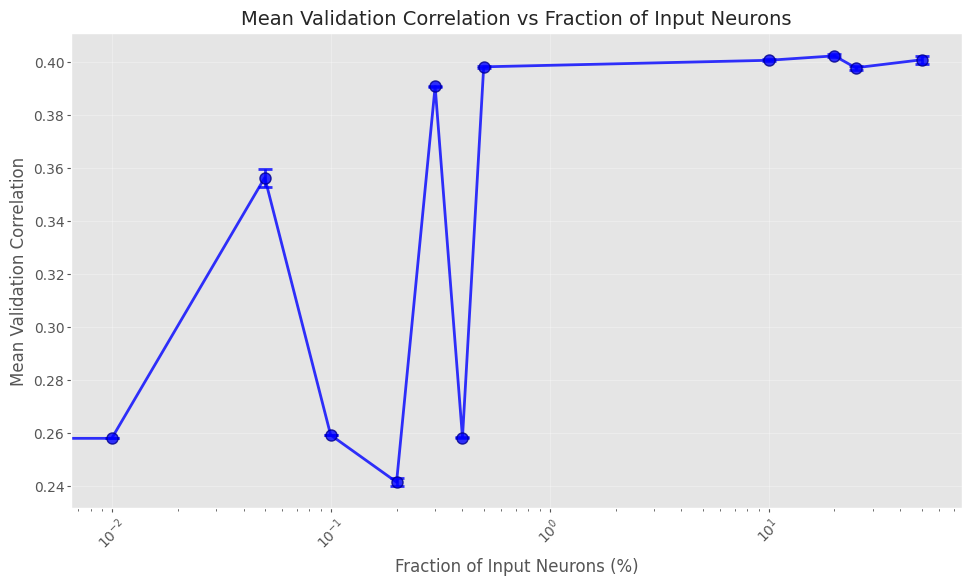

In [61]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.errorbar(fractions, means, yerr=stds, marker='o', linewidth=2, markersize=8, 
             capsize=5, capthick=2, elinewidth=2, markerfacecolor='blue', 
             markeredgecolor='darkblue', color='blue', alpha=0.8)

plt.xlabel('Fraction of Input Neurons (%)', fontsize=12)
plt.ylabel('Mean Validation Correlation', fontsize=12)
plt.title('Mean Validation Correlation vs Fraction of Input Neurons', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xscale('log')

# Add some formatting
plt.xticks(fractions, [f'{f}%' for f in fractions], rotation=45)
plt.tight_layout()
plt.xscale('log')
# Show statistics
print(f"\nBest performance: {means.max():.4f} ± {stds[np.argmax(means)]:.4f} at {fractions[np.argmax(means)]}%")
print(f"Worst performance: {means.min():.4f} ± {stds[np.argmin(means)]:.4f} at {fractions[np.argmin(means)]}%")

plt.show()

In [62]:
# First, let's clear CUDA memory and check usage
import gc
torch.cuda.empty_cache()
gc.collect()

print("CUDA Memory Usage:")
print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

CUDA Memory Usage:
Allocated: 0.01 GB
Reserved: 0.02 GB


In [63]:
@torch.no_grad()
def memory_efficient_evaluate_model(
    ds: t.Dict,
    model: Model,
    device: torch.device,
    verbose: bool = True,
    max_iterations: int = 25,
    clear_cache_every: int = 5,  # Clear cache every N iterations
):
    """Memory-efficient version with aggressive cleanup"""
    
    # Clear memory before starting
    torch.cuda.empty_cache()
    gc.collect()
    
    model.to(device).eval()
    results = {}
    
    for mouse_id, ds in ds.items():
        print(f"\nProcessing mouse: {mouse_id}")
        
        frac_input_neurons = getattr(model, "frac_input_neurons", 0.0)
        N = ds.dataset.num_neurons
        print(f"Fraction: {frac_input_neurons}, N neurons: {N}")
        
        if frac_input_neurons == 0.:
            # Single evaluation for fraction 0
            targets, predictions = [], [] 
            
            for batch_idx, batch in enumerate(tqdm(ds, desc=f"Mouse {mouse_id}")):
                # Process in smaller chunks and clear intermediate tensors
                with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                    y_true = batch["response"].to(device)
                    y_pred, _, _ = model(
                        images=batch["image"].to(device),
                        responses=batch["response"].to(device),
                        neuron_coords=batch["neuron_coordinates"].to(device),
                        input_neuron_ids=None,
                        query_neuron_ids=torch.arange(N).to(device),
                        mouse_id=mouse_id,
                        behaviors=batch["behavior"].to(device),
                        pupil_centers=batch["pupil_center"].to(device),
                    )
                    
                    # Move to CPU immediately to save GPU memory
                    targets.append(y_true.cpu())
                    predictions.append(y_pred.cpu())
                    
                    # Clear GPU tensors
                    del y_true, y_pred
                    
                    # Periodic cache clearing
                    if batch_idx % clear_cache_every == 0:
                        torch.cuda.empty_cache()
                        
            targets = torch.vstack(targets)
            predictions = torch.vstack(predictions)
            results[mouse_id] = compute_metrics(y_true=targets, y_pred=predictions)
            
            # Clear everything
            del targets, predictions
            torch.cuda.empty_cache()
            gc.collect()

        else:
            # Multiple iterations for non-zero fractions
            all_results = []
            
            for i in range(max_iterations):
                print(f"Iteration {i+1}/{max_iterations}")
                
                # Create new permutation
                perm = torch.randperm(N, device=device)
                K = int(frac_input_neurons * N)
                input_neuron_ids = perm[:K]
                query_neuron_ids = perm[K:]
                
                targets, predictions = [], []
                
                for batch_idx, batch in enumerate(tqdm(ds, desc=f"Iter {i+1}", leave=False)):
                    with autocast(device_type=device.type, enabled=scaler.is_enabled(), dtype=torch.float16):
                        y_true = batch["response"].to(device)[:, query_neuron_ids]
                        y_pred, _, _ = model(
                            images=batch["image"].to(device),
                            responses=batch["response"].to(device),
                            neuron_coords=batch["neuron_coordinates"].to(device),
                            input_neuron_ids=input_neuron_ids,
                            query_neuron_ids=query_neuron_ids,
                            mouse_id=mouse_id,
                            behaviors=batch["behavior"].to(device),
                            pupil_centers=batch["pupil_center"].to(device),
                        )
                        
                        # Move to CPU immediately
                        targets.append(y_true.cpu())
                        predictions.append(y_pred.cpu())
                        
                        # Clear GPU tensors
                        del y_true, y_pred
                        
                        # Periodic cache clearing
                        if batch_idx % clear_cache_every == 0:
                            torch.cuda.empty_cache()
                
                # Compute metrics for this iteration
                targets = torch.vstack(targets)
                predictions = torch.vstack(predictions)
                iteration_results = compute_metrics(y_true=targets, y_pred=predictions)
                
                # Extract scalar values and store
                scalar_results = {}
                for key, value in iteration_results.items():
                    scalar_results[key] = value.item() if hasattr(value, 'item') else value
                all_results.append(scalar_results)
                
                # Clear iteration data
                del targets, predictions, iteration_results, scalar_results
                del input_neuron_ids, query_neuron_ids, perm
                
                # Aggressive cleanup every few iterations
                if i % clear_cache_every == 0:
                    torch.cuda.empty_cache()
                    gc.collect()
            
            # Aggregate results
            mouse_results = {}
            for key in all_results[0].keys():
                values = [result[key] for result in all_results]
                mouse_results[f"{key}_mean"] = np.mean(values)
                mouse_results[f"{key}_std"] = np.std(values)
                mouse_results[f"{key}_all"] = values
        
            results[mouse_id] = mouse_results
            del all_results

        # Final cleanup for this mouse
        torch.cuda.empty_cache()
        gc.collect()
        
        # Print memory usage
        print(f"Memory after mouse {mouse_id}: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

    return results

In [ ]:
def evaluate_all_fractions_safely(model, val_ds, device, fractions_to_test=None):
    """
    Safely evaluate all fractions by setting model attributes and clearing memory between runs
    """
    if fractions_to_test is None:
        fractions_to_test = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 10, 20, 25, 50]
    
    all_results = {}
    
    for fraction in fractions_to_test:
        print(f"\n{'='*50}")
        print(f"EVALUATING FRACTION: {fraction}")
        print(f"{'='*50}")
        
        # Clear everything before each evaluation
        torch.cuda.empty_cache()
        gc.collect()
        
        # Set the fraction on the model
        model.frac_input_neurons = fraction
        
        try:
            # Run evaluation with memory-efficient function
            results = memory_efficient_evaluate_model(
                ds=val_ds,
                model=model,
                device=device,
                verbose=True,
                max_iterations=25 if fraction > 0 else 1,
                clear_cache_every=3  # More frequent clearing
            )
            
            all_results[f"fraction_{fraction}"] = results
            print(f"✓ Successfully completed fraction {fraction}")
            
        except torch.cuda.OutOfMemoryError as e:
            print(f"✗ CUDA OOM for fraction {fraction}: {e}")
            # Emergency cleanup
            torch.cuda.empty_cache()
            gc.collect()
            continue
        except Exception as e:
            print(f"✗ Error for fraction {fraction}: {e}")
            continue
        
        # Always clear after each fraction
        torch.cuda.empty_cache()
        gc.collect()
        
        print(f"Memory after fraction {fraction}: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    
    return all_results

# Example usage (uncomment to run):
# all_fraction_results = evaluate_all_fractions_safely(
#     model=model, 
#     val_ds=val_ds, 
#     device=args.device,
#     fractions_to_test=[0.0, 0.01, 0.05, 0.1]  # Start with a few fractions
# )

In [64]:
# IMMEDIATE FIXES - Run this now to clear memory issues:

print("=== EMERGENCY MEMORY CLEANUP ===")

# 1. Clear all variables that might be holding CUDA tensors
variables_to_clear = [
    'mouse_results_0'
]

for var_name in variables_to_clear:
    if var_name in globals():
        print(f"Clearing {var_name}")
        del globals()[var_name]

# 2. Garbage collection
import gc
gc.collect()

# 3. Clear CUDA cache
torch.cuda.empty_cache()

# 4. Check current memory usage
print(f"\nMemory after cleanup:")
print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

# 5. Reset CUDA if needed (uncomment if still having issues)
# torch.cuda.reset_peak_memory_stats()
# torch.cuda.empty_cache()

print("\n=== MEMORY CLEANUP COMPLETE ===")

# 6. Additional recommendations:
print("\nRECOMMENDATIONS:")
print("1. Reduce batch_size in args (try batch_size=1 or 2)")
print("2. Use smaller max_iterations (try 10 instead of 25)") 
print("3. Process one fraction at a time")
print("4. Restart kernel if problems persist")

=== EMERGENCY MEMORY CLEANUP ===
Clearing mouse_results_0

Memory after cleanup:
Allocated: 0.01 GB
Reserved: 0.02 GB

=== MEMORY CLEANUP COMPLETE ===

RECOMMENDATIONS:
1. Reduce batch_size in args (try batch_size=1 or 2)
2. Use smaller max_iterations (try 10 instead of 25)
3. Process one fraction at a time
4. Restart kernel if problems persist
